# Stage 1 Dashboard (Process-then-Load)

Load data produced by `05_process_data.py` and plot the 5-row dashboard (Density, Polar, Semi-Log, Beta, Scaling) plus summary table.

In [11]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%load_ext autoreload
%autoreload 2
from src.analysis import processing as proc
from src.analysis import plotting as viz
from src.analysis import metrics

PROCESSED_DIR = os.path.join(project_root, 'results', 'processed')
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['figure.dpi'] = 120
print(f"Loading from {PROCESSED_DIR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading from /Users/ramsaydavis/dla/results/processed


In [12]:
# Which model/size combos to load (must have been produced by 05_process_data.py)
MODELS = ["OffLattice", "Lattice", "Hybrid"]
SIZES = ["1M", "10M"]

In [13]:
# Load all saved data and compute anisotropy metrics on-the-fly from 360-sector grid
datasets = []
for model in MODELS:
    for size in SIZES:
        base = f"{model}_{size}"
        scalars_path = os.path.join(PROCESSED_DIR, f"{base}_scalars.csv")
        sectors_path = os.path.join(PROCESSED_DIR, f"{base}_sectors.npz")
        density_path = os.path.join(PROCESSED_DIR, f"{base}_density.npz")
        if not os.path.isfile(scalars_path) or not os.path.isfile(sectors_path) or not os.path.isfile(density_path):
            continue
        df_scalars = pd.read_csv(scalars_path)
        sec = np.load(sectors_path, allow_pickle=True)
        times = np.atleast_1d(sec["times"])
        grid = sec["grid"]
        den = np.load(density_path, allow_pickle=True)
        grid_d = den["grid"]
        bins_d = den["bins"]
        max_r = den["max_r"]
        rg = den["rg"]
        if grid.size > 0 and len(times) > 0:
            df_metrics, summary = proc.compute_anisotropy_metrics(times, grid)
            summary["beta_axis_mean"] = df_metrics["beta_axis"].mean()
            summary["beta_diag_mean"] = df_metrics["beta_diag"].mean()
        else:
            summary = {"beta_ratio_mean": np.nan, "beta_ratio_std": np.nan,
                       "fourier_score_mean": np.nan, "fourier_score_std": np.nan,
                       "beta_axis_mean": np.nan, "beta_diag_mean": np.nan}
        datasets.append({
            "name": f"{model} ({size})",
            "model": model,
            "size": size,
            "df_scalars": df_scalars,
            "times": times,
            "sector_data": grid,
            "summary": summary,
            "grid": grid_d,
            "bins": bins_d,
            "max_r": max_r,
            "rg": rg,
        })
print(f"Loaded {len(datasets)} dataset(s).")

Computing anisotropy metrics for 1000 files...


Anisotropy Metrics:   0%|          | 0/1000 [00:00<?, ?it/s]/Users/ramsaydavis/dla/src/analysis/metrics.py:137: RuntimeWarning: Mean of empty slice
  grid_coarse = np.nanmean(grid_reshaped, axis=1)
Anisotropy Metrics: 100%|██████████| 1000/1000 [01:24<00:00, 11.82it/s]


Computing anisotropy metrics for 100 files...


Anisotropy Metrics:   0%|          | 0/100 [00:00<?, ?it/s]/Users/ramsaydavis/dla/src/analysis/metrics.py:137: RuntimeWarning: Mean of empty slice
  grid_coarse = np.nanmean(grid_reshaped, axis=1)
Anisotropy Metrics: 100%|██████████| 100/100 [00:07<00:00, 12.62it/s]


Computing anisotropy metrics for 1000 files...


...

Computing anisotropy metrics for 1000 files...


Anisotropy Metrics:   0%|          | 0/1000 [00:00<?, ?it/s]/Users/ramsaydavis/dla/src/analysis/metrics.py:137: RuntimeWarning: Mean of empty slice
  grid_coarse = np.nanmean(grid_reshaped, axis=1)
Anisotropy Metrics: 100%|██████████| 1000/1000 [01:09<00:00, 14.40it/s]


Computing anisotropy metrics for 100 files...


Anisotropy Metrics:   0%|          | 0/100 [00:00<?, ?it/s]/Users/ramsaydavis/dla/src/analysis/metrics.py:137: RuntimeWarning: Mean of empty slice
  grid_coarse = np.nanmean(grid_reshaped, axis=1)
Anisotropy Metrics: 100%|██████████| 100/100 [00:06<00:00, 14.61it/s]

Loaded 6 dataset(s).


/Users/ramsaydavis/dla/src/analysis/plotting.py:58: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(agg_data, axis=0)  # shape: (num_sectors, time_points)
/Users/ramsaydavis/dla/src/analysis/plotting.py:240: RuntimeWarning: Mean of empty slice
  mean_r_matrix = np.nanmean(agg_data, axis=0)  # average across all clusters (sectors x time)
/Users/ramsaydavis/dla/src/analysis/plotting.py:149: RuntimeWarning: Mean of empty slice
  mean_grid = np.nanmean(agg_data, axis=0)


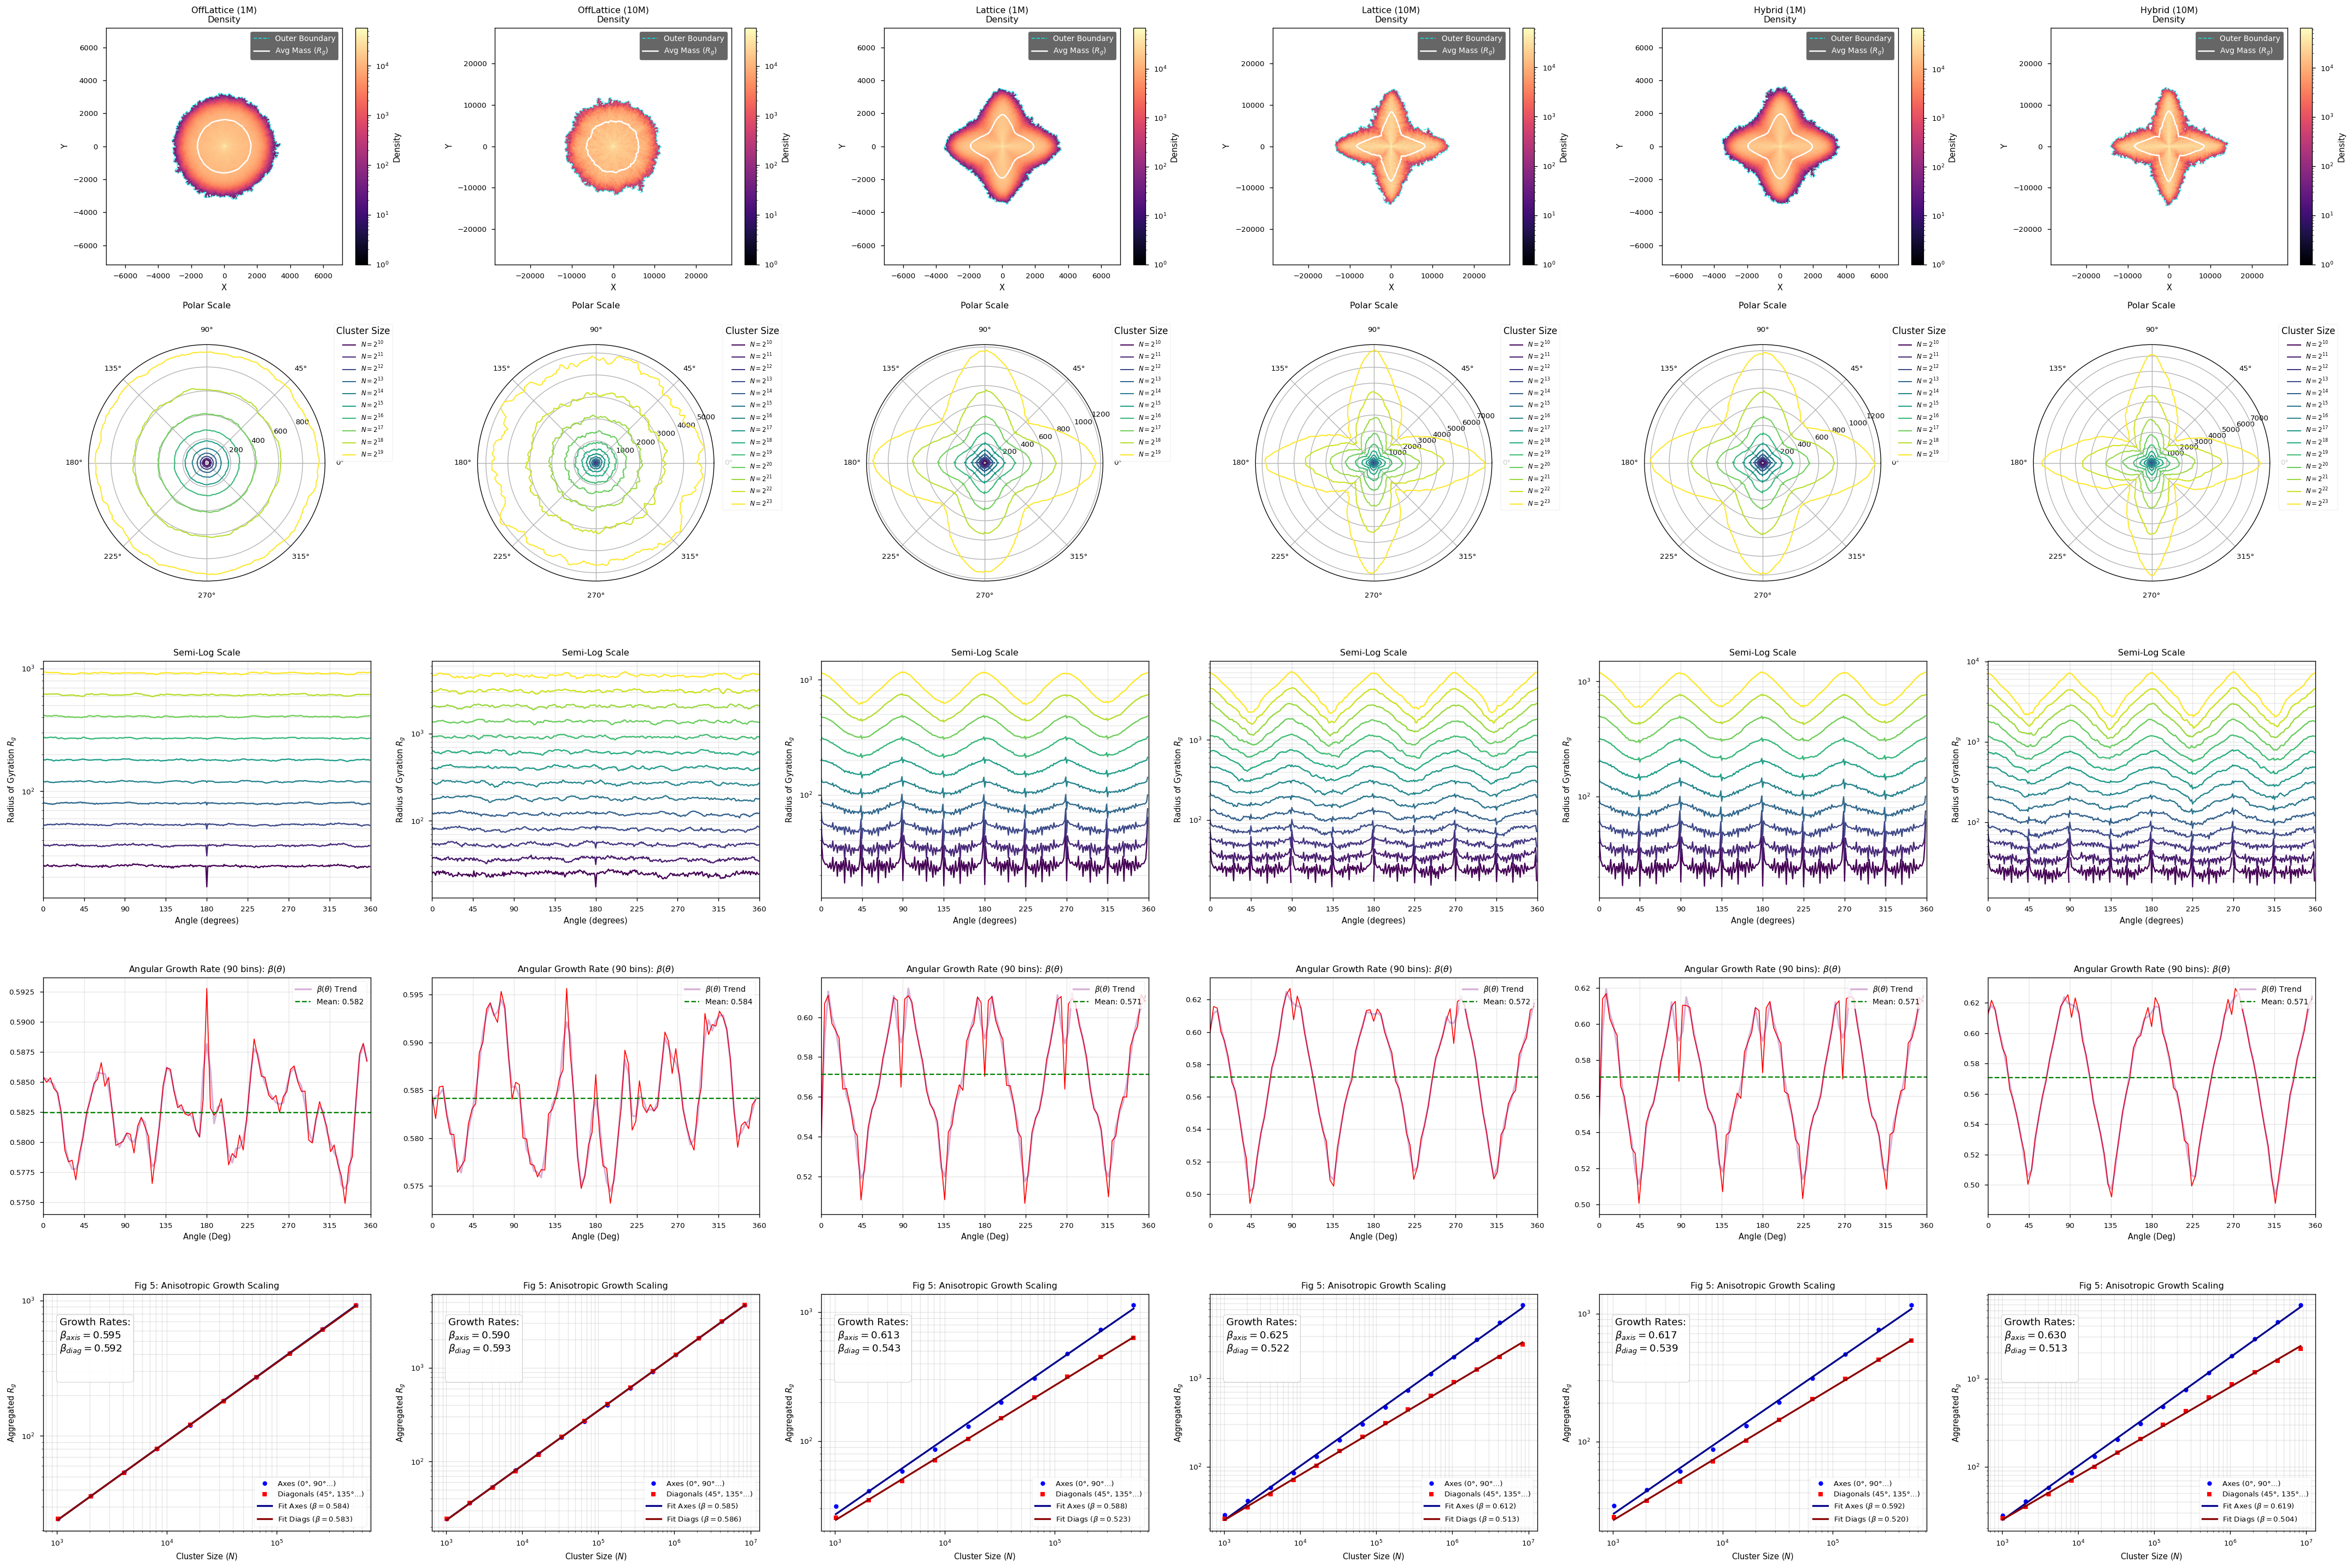

In [15]:
# Dashboard: 5 rows per (model, size)
num_models = len(datasets)
if num_models == 0:
    print("No datasets loaded. Run 05_process_data.py first.")
else:
    fig = plt.figure(figsize=(6 * num_models, 24))
    for i, item in enumerate(datasets):
        name = item["name"]
        times = item["times"]
        data = item["sector_data"]
        summary = item["summary"]
        # Row 1: Density
        ax1 = fig.add_subplot(5, num_models, i + 1)
        if item["grid"] is not None and item["grid"].size > 0:
            viz.plot_density_map(item["grid"], item["bins"], max_r_curve=item["max_r"], rg_curve=item["rg"], title=f"{name}\nDensity", ax=ax1)
        else:
            ax1.text(0.5, 0.5, "Density\n(no data)", ha="center", va="center")
            ax1.set_title(name)
        # Row 2: Polar
        ax2 = fig.add_subplot(5, num_models, num_models + i + 1, projection="polar")
        # Row 3: Semi-Log
        ax3 = fig.add_subplot(5, num_models, 2 * num_models + i + 1)
        viz.angular_rg_plot(times, data, ax_polar=ax2, ax_log=ax3)
        # Row 4: Growth rate (Beta) — pass 360-sector grid; plot_beta_profile downsamples to 90 internally
        ax4 = fig.add_subplot(5, num_models, 3 * num_models + i + 1)
        viz.plot_beta_profile(times, data, ax=ax4)
        # Row 5: Scaling laws
        ax5 = fig.add_subplot(5, num_models, 4 * num_models + i + 1)
        viz.comparing_axes_plot(times, data, summary_stats=summary, ax=ax5)
    plt.tight_layout()
    plt.show()

In [14]:
# Summary table: D = 1/β per row then mean ± std; anisotropy from loaded sector grids
summary_rows = []
for item in datasets:
    df = item["df_scalars"]
    stats = item["summary"]
    valid_beta = df["beta"].dropna()
    valid_beta = valid_beta[valid_beta > 1e-10]
    if len(valid_beta) > 0:
        D_from_beta = 1.0 / valid_beta
        dim_mean, dim_std = D_from_beta.mean(), D_from_beta.std()
        beta_mean, beta_std = valid_beta.mean(), valid_beta.std()
    else:
        dim_mean = dim_std = beta_mean = beta_std = np.nan
    if 'D' in df.columns:
        valid_D = df['D'].dropna()
        valid_D = valid_D[valid_D > 0] # Filter out failures
        
        if len(valid_D) > 0:
            # Calculate simple statistics
            d_box_mean = valid_D.mean()
            d_box_std = valid_D.std()
        else:
            d_box_mean, d_box_std = np.nan, np.nan
    else:
        d_box_mean, d_box_std = np.nan, np.nan
    summary_rows.append({
        "Model": item["name"],
        "Growth rate (β)": f"{beta_mean:.3f} ± {beta_std:.3f}" if not np.isnan(beta_mean) else "—",
        "Dimension (1/β)": f"{dim_mean:.3f} ± {dim_std:.3f}" if not np.isnan(dim_mean) else "—",
        "Box Dim (D)": f"{d_box_mean:.3f} ± {d_box_std:.3f}" if not np.isnan(d_box_mean) else "—",
        "Anisotropy ratio": f"{stats['beta_ratio_mean']:.3f} ± {stats['beta_ratio_std']:.3f}",
        "Fourier score": f"{stats['fourier_score_mean']:.3f} ± {stats['fourier_score_std']:.3f}",
    })
df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Model,Growth rate (β),Dimension (1/β),Box Dim (D),Anisotropy ratio,Fourier score
0,OffLattice (1M),0.584 ± 0.007,1.713 ± 0.020,1.651 ± 0.003,1.010 ± 0.107,0.036 ± 0.018
1,OffLattice (10M),0.584 ± 0.005,1.712 ± 0.016,1.668 ± 0.001,0.998 ± 0.074,0.025 ± 0.013
2,Lattice (1M),0.596 ± 0.008,1.678 ± 0.023,1.657 ± 0.003,1.138 ± 0.121,0.047 ± 0.022
3,Lattice (10M),0.609 ± 0.007,1.643 ± 0.019,1.672 ± 0.002,1.203 ± 0.094,0.052 ± 0.018
4,Hybrid (1M),0.599 ± 0.008,1.671 ± 0.023,1.656 ± 0.003,1.153 ± 0.127,0.049 ± 0.023
5,Hybrid (10M),0.612 ± 0.007,1.634 ± 0.018,1.672 ± 0.002,1.235 ± 0.097,0.057 ± 0.017
